<a href="https://colab.research.google.com/github/TimofeyProtasov/diploma/blob/main/days/first_graphics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Путь для сохранения CSV
SAVE_DIR = "/content/drive/MyDrive/rag_experiments"

Mounted at /content/drive


In [4]:
def load_all_results(save_dir: str) -> pd.DataFrame:
    all_files = Path(save_dir).glob("results_train_*.csv")
    df_list = []
    for file in all_files:
        df = pd.read_csv(file)
        df_list.append(df)
    if df_list:
        return pd.concat(df_list, ignore_index=True)
    else:
        return pd.DataFrame()

df_all = load_all_results(SAVE_DIR)
print(df_all)

   train_size  trainable_params_m  before_train_peak_memory_gb  \
0         100            0.540672                         1.43   
1         300            0.540672                         1.45   
2         500            0.540672                         1.45   
3         700            0.540672                         1.45   

   train_time_min  train_peak_memory_gb    f1  evaluate_f1_time_min  \
0            1.17                  9.87  0.00                  1.82   
1            3.45                  9.87  0.30                  1.87   
2            5.71                  9.87  0.55                  1.56   
3            8.07                  9.87  0.50                  1.64   

   evaluate_f1_peak_memory_gb  perplexity  evaluate_perplexity_time_min  ...  \
0                        1.34        2.18                          0.05  ...   
1                        1.32        1.74                          0.05  ...   
2                        1.30        1.53                          0.05  

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Вручную соберём длинный формат
records = []
for _, row in df_all.iterrows():
    train_size = row['train_size']
    for ep in [4, 8, 12]:
        records.append({
            'train_size': train_size,
            'epoch': ep,
            'f1': row[f'f1_epoch{ep}'],
            'perplexity': row[f'perplexity_epoch{ep}'],
            'f1_time': row[f'f1_time_epoch{ep}'],
            'f1_memory': row[f'f1_memory_epoch{ep}'],
            'perplexity_time': row[f'perplexity_time_epoch{ep}'],
            'perplexity_memory': row[f'perplexity_memory_epoch{ep}'],
            'train_time': row['train_time_min'],
            'train_memory': row['train_peak_memory_gb']
        })

df_long = pd.DataFrame(records)


In [11]:
df_long

,train_size,epoch,f1,perplexity,f1_time,f1_memory,perplexity_time,perplexity_memory,train_time,train_memory
0,100.0,4,0.00,2.52,0.96,1.34,0.05,3.26,1.17,9.87
1,100.0,8,0.00,2.30,1.61,1.34,0.05,3.26,1.17,9.87
2,100.0,12,0.00,2.18,1.82,1.34,0.05,3.26,1.17,9.87
3,300.0,4,0.00,2.02,1.61,1.31,0.05,3.01,3.45,9.87
4,300.0,8,0.13,1.81,1.58,1.32,0.05,3.01,3.45,9.87
5,300.0,12,0.30,1.74,1.87,1.32,0.05,3.01,3.45,9.87
6,500.0,4,0.33,1.63,1.59,1.30,0.05,3.20,5.71,9.87
7,500.0,8,0.52,1.55,1.36,1.31,0.05,3.20,5.71,9.87
8,500.0,12,0.55,1.53,1.56,1.30,0.05,3.20,5.71,9.87
9,700.0,4,0.39,1.64,1.61,1.36,0.05,3.13,8.07,9.87


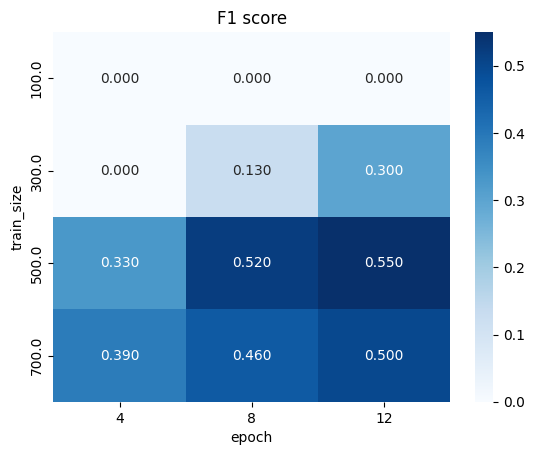

In [12]:

# 2. Heatmap (пример для f1)
pivot_f1 = df_long.pivot(index='train_size', columns='epoch', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1 score')
plt.show()


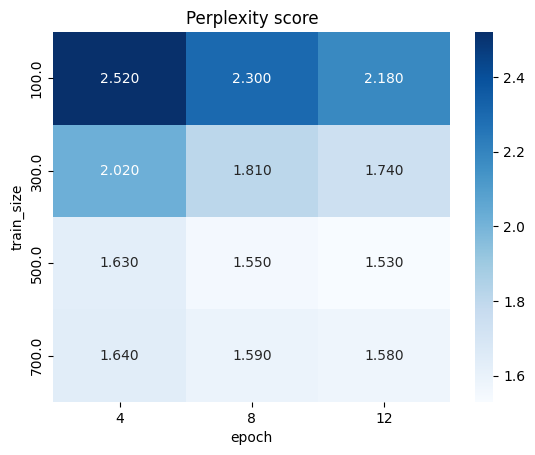

In [17]:

# 2. Heatmap (пример для f1)
pivot_per = df_long.pivot(index='train_size', columns='epoch', values='perplexity')
sns.heatmap(pivot_per, annot=True, fmt='.3f', cmap='Blues')
plt.title('Perplexity score')
plt.show()


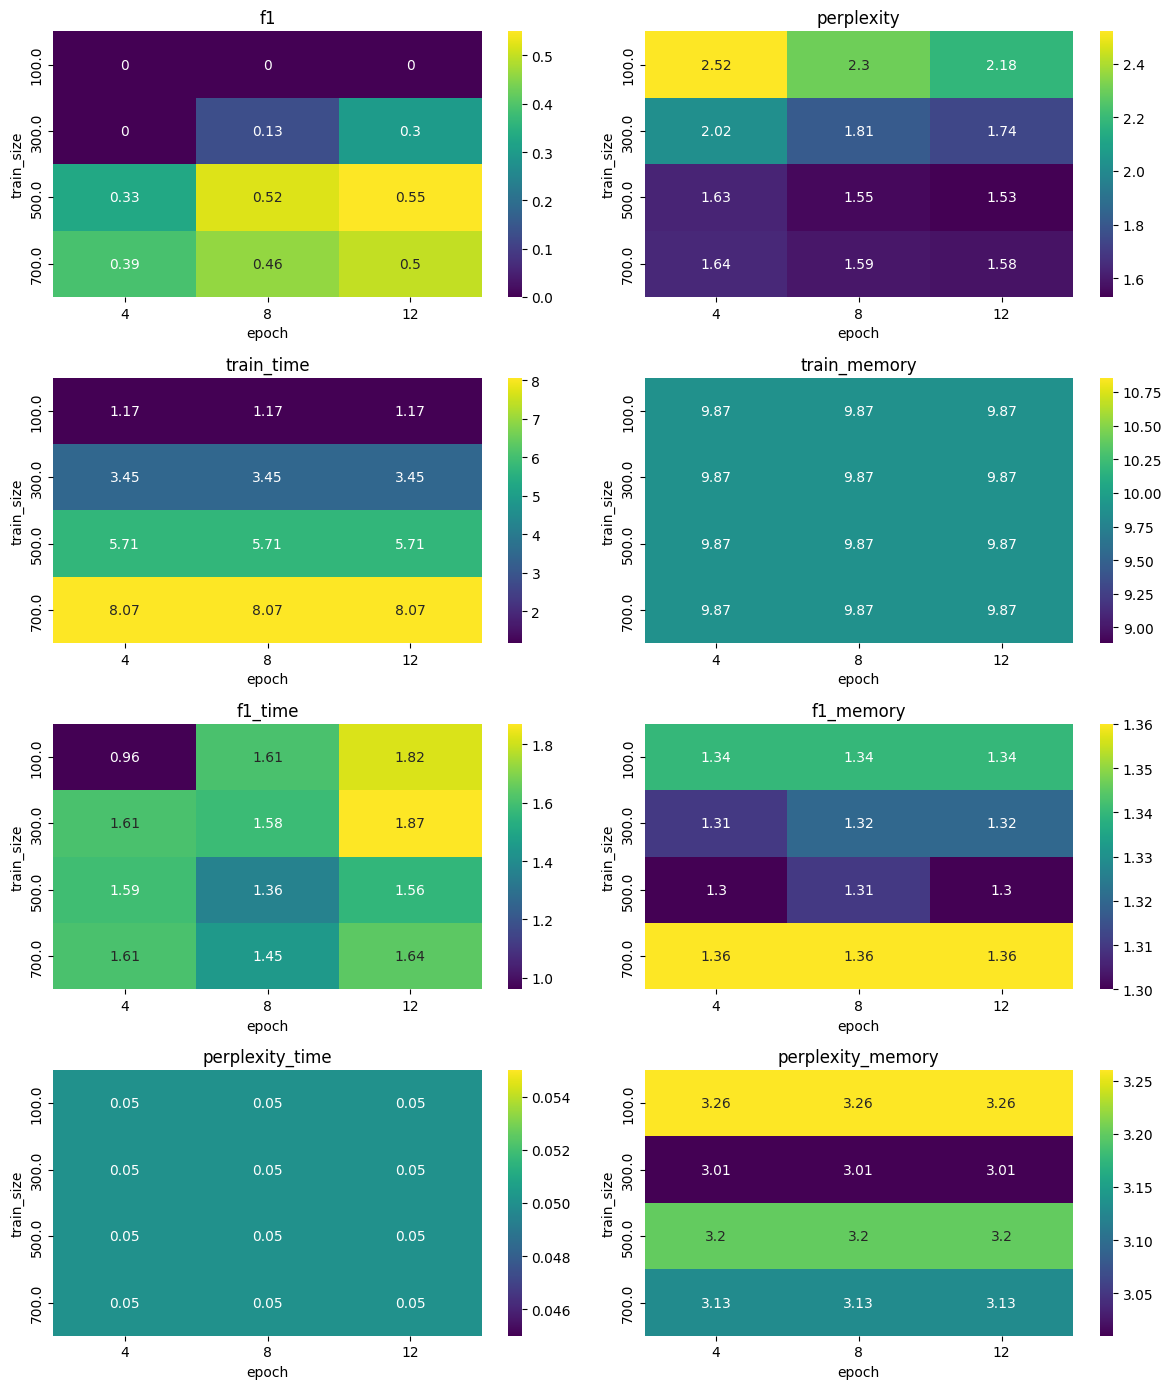

In [13]:

# 3. Все метрики в одном цикле
metrics = ['f1', 'perplexity', 'train_time', 'train_memory',
           'f1_time', 'f1_memory', 'perplexity_time', 'perplexity_memory']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    pivot = df_long.pivot(index='train_size', columns='epoch', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3g', cmap='viridis', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('epoch')
    ax.set_ylabel('train_size')
plt.tight_layout()
plt.show()

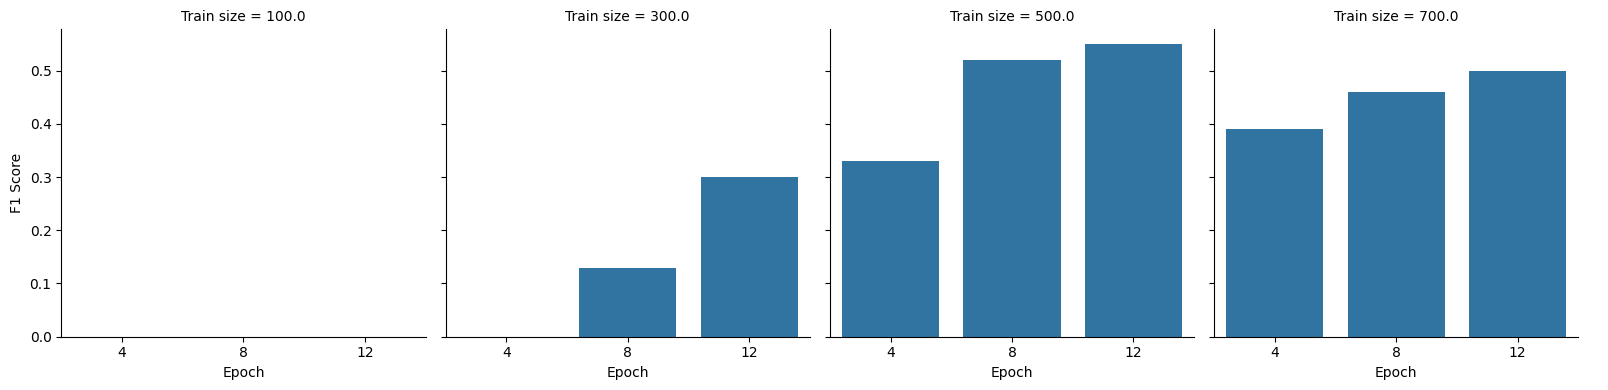

In [15]:
g = sns.catplot(data=df_long, x='epoch', y='f1', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "F1 Score")
g.set_titles("Train size = {col_name}")
plt.show()

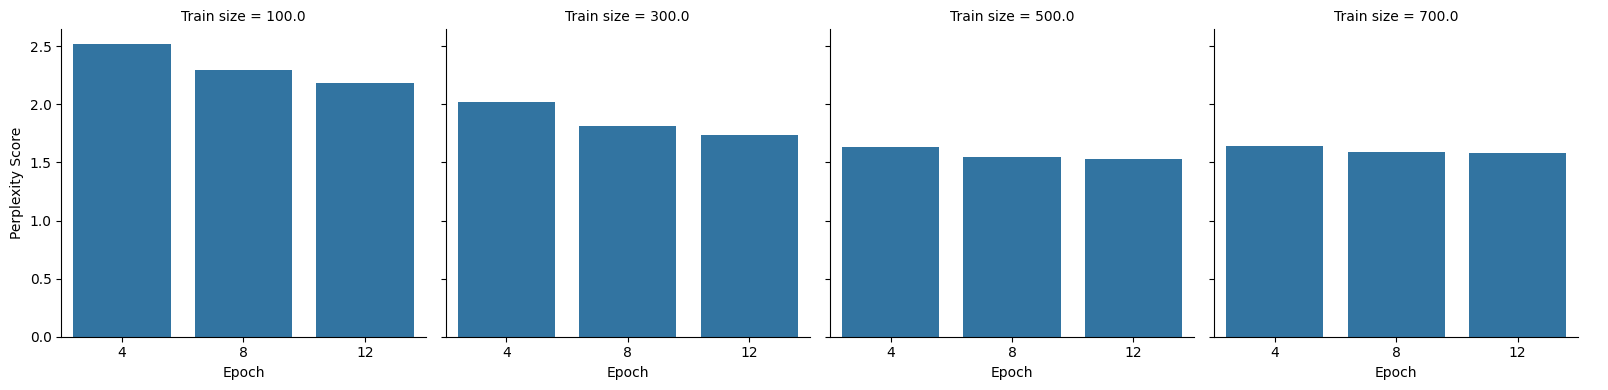

In [18]:
g = sns.catplot(data=df_long, x='epoch', y='perplexity', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "Perplexity Score")
g.set_titles("Train size = {col_name}")
plt.show()

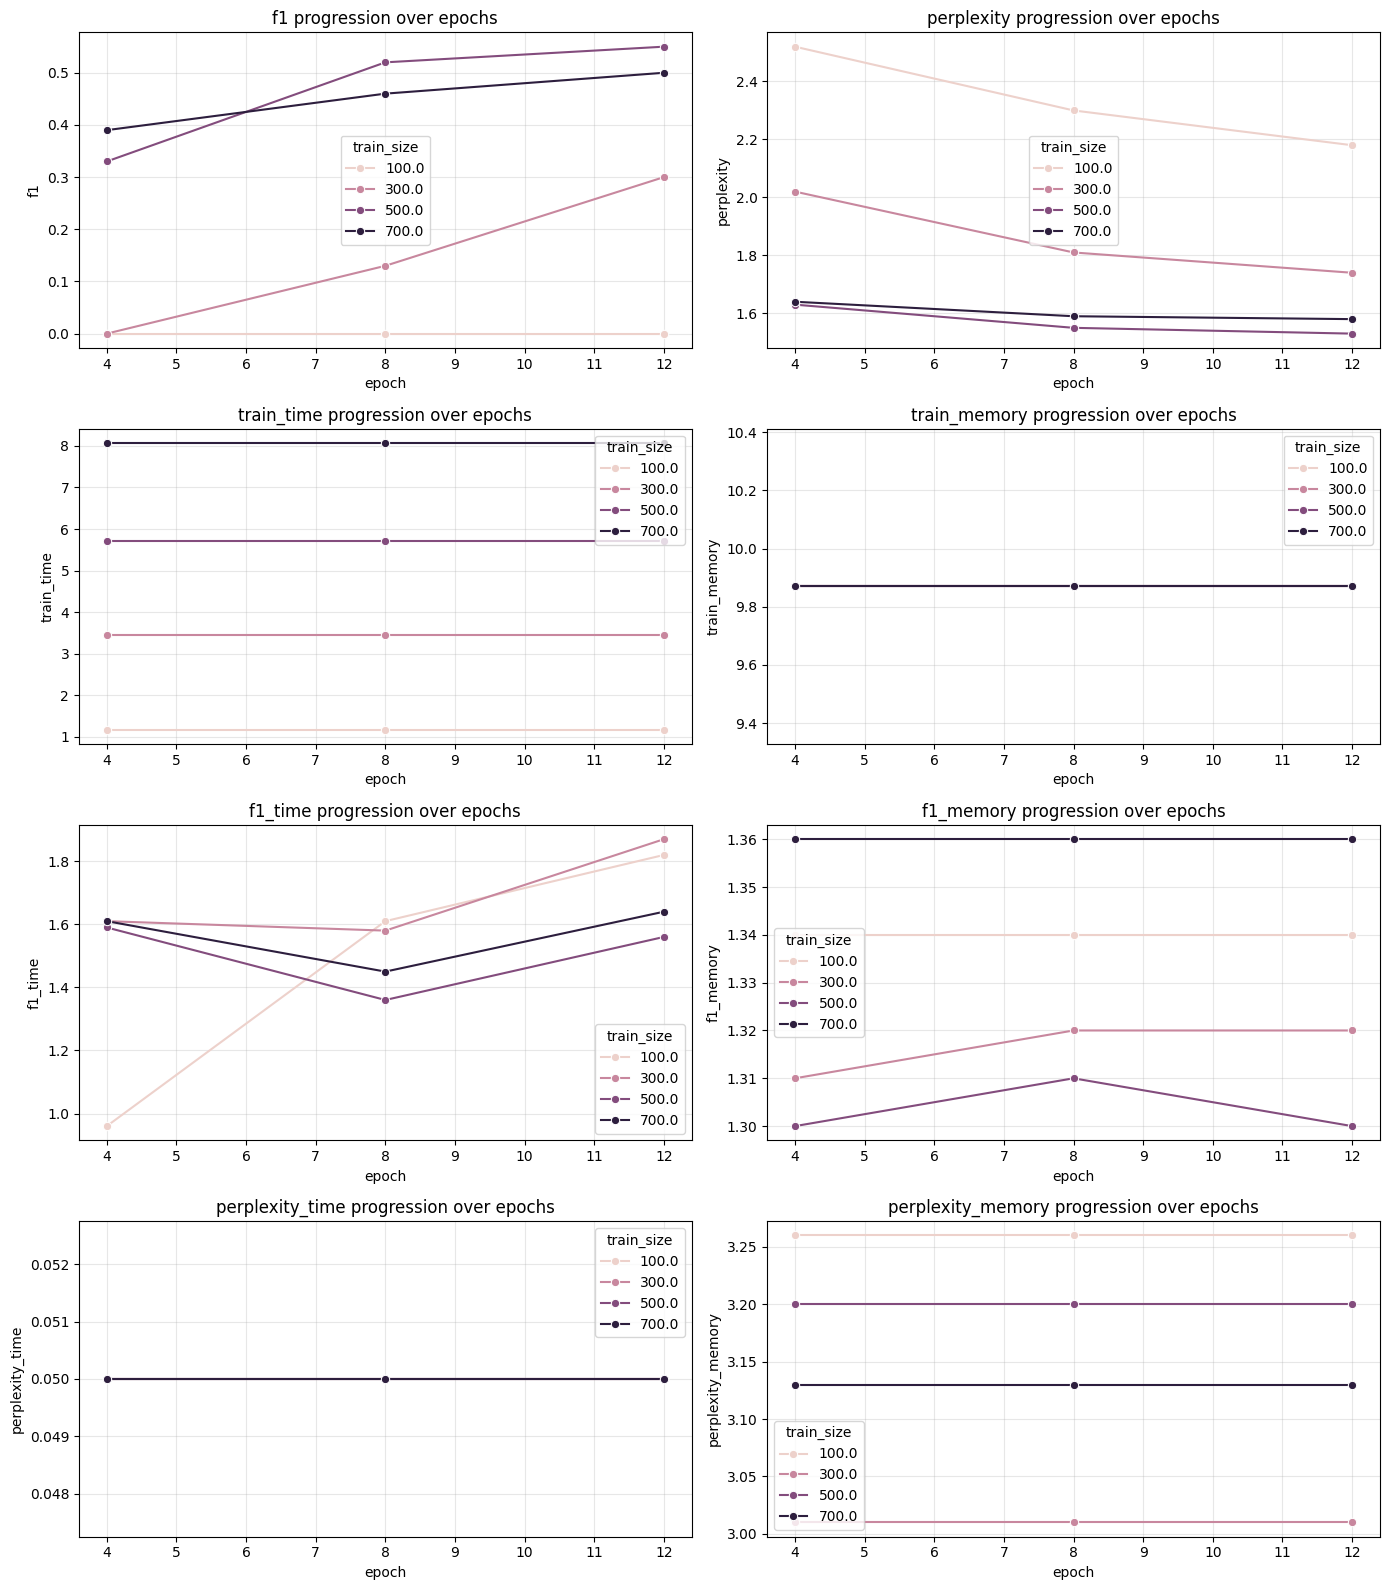

In [16]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_long, x='epoch', y=metric, hue='train_size',
                 marker='o', ax=ax)
    ax.set_title(f'{metric} progression over epochs')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()